In [1]:
import edes 
from edes.experiments import Experiment
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.circuits import dBm_to_Vp, dBm_to_W, Vp_to_dBm
from edes.modules.trap_drive.utils import beep
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.experiments.sequences import base as sequences
from edes.experiments.sequences import calibration

from edes.experiments.devices.base import Instrument
from edes.modules.variable_attenuator import var_attn_utils
from edes.utils.file_handling import load_latest_data
from edes.utils.utils import beep_jupyter, U2_to_MHz
from typing import TYPE_CHECKING

# 1. This code block ONLY runs in your IDE for auto-complete
# It is completely ignored when the code actually runs
if TYPE_CHECKING:
    from edes.experiments.devices.base import *
big_plt_font()

In [2]:
exp = Experiment('3layer_trapping_072326')

>>> ERROR connecting to RigolDG4062 at TCPIP::192.168.169.104::INSTR: VI_ERROR_RSRC_NFOUND (-1073807343): Insufficient location information or the requested device or resource is not present in the system.
>>> ERROR initializing device AWG: 'RigolDG4062' object has no attribute 'instrument'
>>> Connected to Agilent Technologies,34461A,MY53200916,A.01.08-02.22-00.08-00.35-01-01

>>> Connected to ARTIQ Zotino.
>>> Connected to RIGOL TECHNOLOGIES,DP832A,DP8B260200018,00.01.19

>>> ERROR connecting to Keithley2100 at USB0::1510::8448::1243106::0::INSTR: No device found.
>>> Connected to Siglent Technologies,SPD3303X-E,SPD3XJEQ6R3773,1.01.01.02.07R2,V3.0

>>> Connected to Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10

>>> Connected to Valon at ASRL/dev/ttyUSB0::INSTR with frequency 1465200000 Hz and power 0 dBm.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


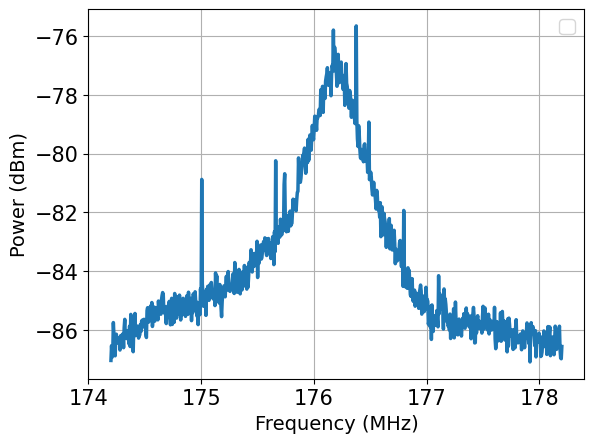

In [4]:
exp.SSA.select_mode('SA')
exp.SSA.set_N_avg(64)
exp.SSA.set_freq_span(4e6)
exp.SSA.set_freq_center(176.200e6)
exp.SSA.set_div_scale(1)
# exp.SSA.set_SWT(100e-3)
exp.SSA.set_RBW(1e3)
exp.SSA.set_VBW(1e3)
exp.SSA.set_ref_level(-68)
freq, data = exp.SSA.measure_freq_spectrum()
plot(freq/1e6, data, xlabel='Frequency (MHz)', ylabel='Power (dBm)')
# plt.axvline(175, linestyle='--', color='r', alpha=0.7, label=f'Urukul applied to tickle line\n70+15dB attenuation\nmeasured {data[np.argmin(abs(freq-175e6))]:.1f}dB')
plt.legend()

In [7]:
exp.FEtip_PSU.set_voltage(0)

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.56s/it]


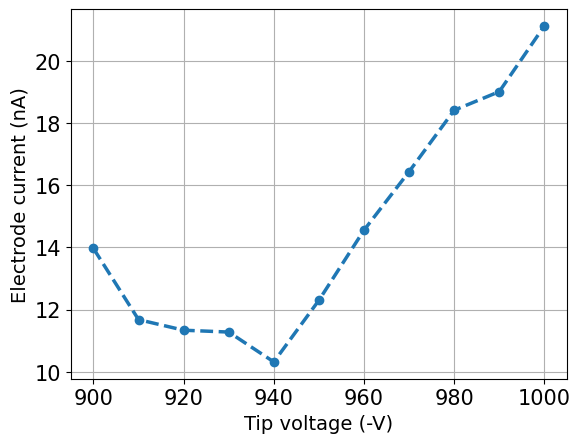

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.59s/it]


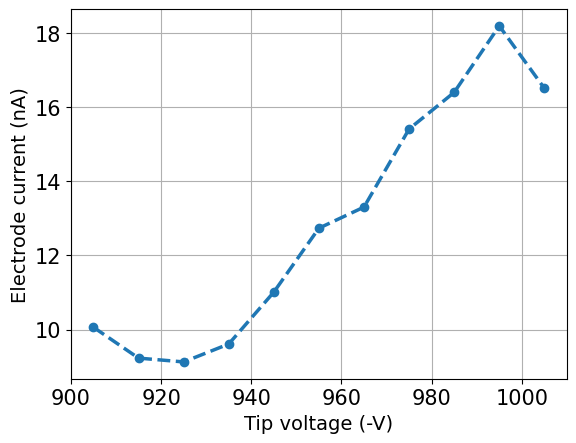

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.57s/it]


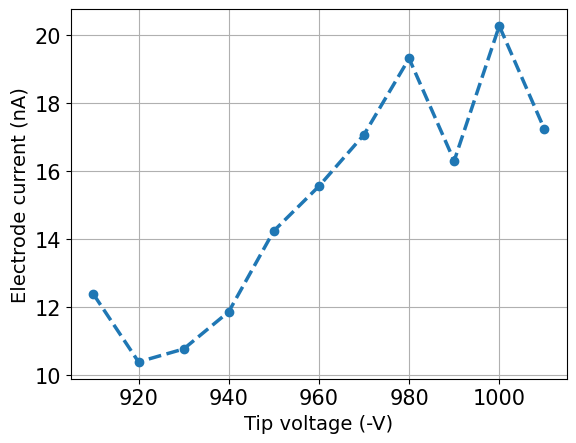

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.56s/it]


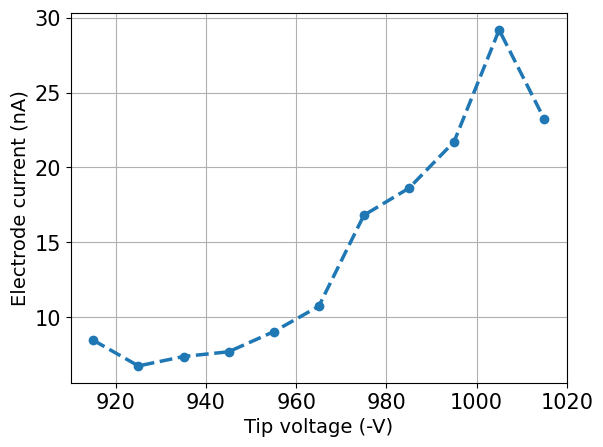

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.58s/it]


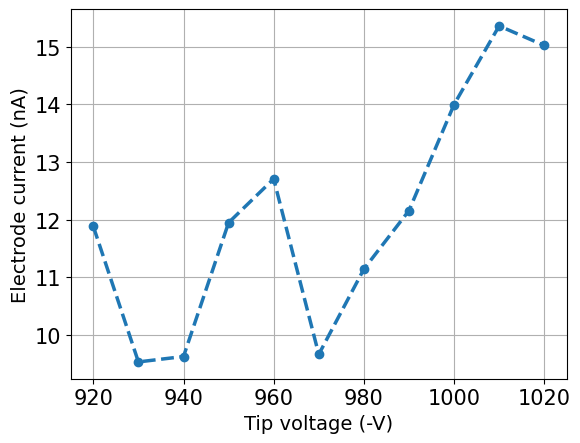

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.56s/it]


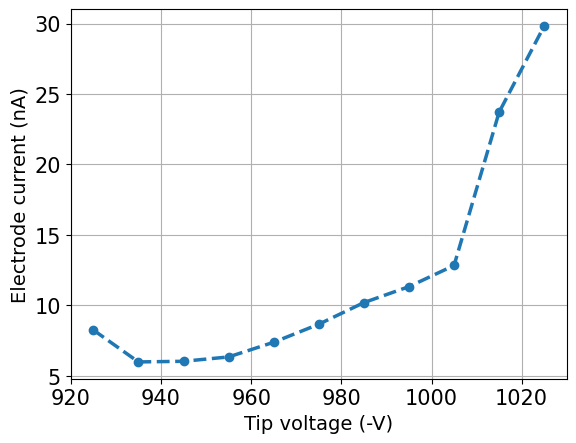

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.55s/it]


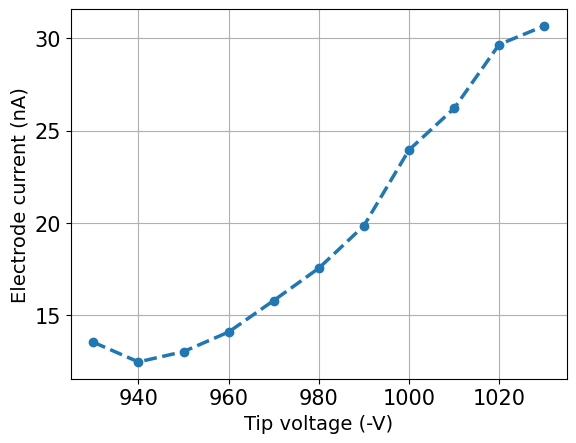

In [4]:
exp.V_tip = 1000
# exp.max_I = 1 
calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=True, I_max=35e-9)

In [16]:
all_Ex = [0.1]

for Ex in all_Ex:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=5, V_on=exp.V_tip, V_off=exp.V_tip-100, V_pos=100,
                                     t_load=30, t_data=1, t_rest=1,
                                     SSA_freq_center=176.212e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.7)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.7, background=True)
    file = RF_sweep.run_save()
    # reset_tip_V(exp, V_pos=1200)

RID: 10380
voltages loaded


100%|███████████████████████████████████████████| 30/30 [16:25<00:00, 32.86s/it]


In [20]:
beep_jupyter()

In [9]:
for Ex in [-0.1, 0, 0.3, 0.5, 0.7]:
    RF_sweep = RFPowerSweepOnOffDifferential(saving_dir=exp.saving_dir, 
                                 P_load=12, P_detect=5, V_on=1100, V_off=950, V_pos=40,
                                 t_load=20, t_data=0.1, t_rest=5,
                                 SSA_freq_center=176.31e6, SSA_freq_span=0,
                                 SSA_RBW=1e3, N_avg=30,
                                 Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                 display_progress=True)
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.7)
    time.sleep(5)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.7, background=False)
    file = RF_sweep.run_save()
# for U2 in [-1, -0.7, -0.4, 1]:
#     exp.DAC.set_multipoles(Ex=0.3, U2=U2)
#     time.sleep(5)
#     RF_sweep.set_parameters(Ex=0.3, U2=U2, background=False)
#     file = RF_sweep.run_save()
beep_jupyter()

RID: 10112
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


RID: 10113
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


RID: 10114
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


RID: 10115
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.22s/it]


RID: 10116
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


In [11]:
for U2 in [-0.4, 1, -1, -0.7]:
    RF_sweep = RFPowerSweepOnOffDifferential(saving_dir=exp.saving_dir, 
                                 P_load=12, P_detect=5, V_on=1100, V_off=950, V_pos=40,
                                 t_load=20, t_data=0.1, t_rest=5,
                                 SSA_freq_center=176.31e6, SSA_freq_span=0,
                                 SSA_RBW=1e3, N_avg=30,
                                 Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                 display_progress=True)
    exp.DAC.set_multipoles(Ex=0.5, U2=U2)
    time.sleep(5)
    RF_sweep.set_parameters(Ex=0.5, U2=U2, background=False)
    file = RF_sweep.run_save()
# for U2 in [-1, -0.7, -0.4, 1]:
#     exp.DAC.set_multipoles(Ex=0.3, U2=U2)
#     time.sleep(5)
#     RF_sweep.set_parameters(Ex=0.3, U2=U2, background=False)
#     file = RF_sweep.run_save()
beep_jupyter()

RID: 10121
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.22s/it]


RID: 10122
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


RID: 10123
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


RID: 10124
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


In [14]:
RF_sweep = RFPowerSweepOnOffDifferential(saving_dir=exp.saving_dir, 
                                 P_load=12, P_detect=5, V_on=1125, V_off=950, V_pos=40,
                                 t_load=20, t_data=0.2, t_rest=5,
                                 SSA_freq_center=176.31e6, SSA_freq_span=0,
                                 SSA_RBW=10e3, N_avg=30,
                                 Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                 display_progress=True)
exp.DAC.set_multipoles(Ex=0.25, U2=-0.4)
time.sleep(5)
RF_sweep.set_parameters(Ex=0.25, U2=-0.4, background=False)
file = RF_sweep.run_save()

RID: 10133
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:39<00:00, 25.32s/it]


In [60]:
RF_sweep = RFPowerSweepRevivalDifferential(saving_dir=exp.saving_dir, 
                                 P_load=12, P_detect=5, V_on=1125, V_off=950, V_pos=40,
                                 t_load=20, t_data=0.2, t_rest=5,
                                 SSA_freq_center=176.320e6, SSA_freq_span=0.5e6,
                                 SSA_RBW=1e3, N_avg=30,
                                 Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                 display_progress=True)
exp.DAC.set_multipoles(Ex=0.25, U2=-0.4)
time.sleep(5)
RF_sweep.set_parameters(Ex=0.25, U2=-0.4, background=False)
file = RF_sweep.run_save()

RID: 10147
voltages loaded


 57%|████████████████████████▎                  | 17/30 [07:27<05:41, 26.30s/it]


KeyboardInterrupt: 

In [13]:
RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=P_detect, P_detect=P_detect, V_on=0, V_off=0, V_pos=0,
                                     t_load=0.1, t_data=1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=10e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    
RF_sweep.set_parameters(Ex=0.25, U2=-0.4, background=True)
file = RF_sweep.run_save()

100%|███████████████████████████████████████████| 30/30 [01:27<00:00,  2.92s/it]


100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


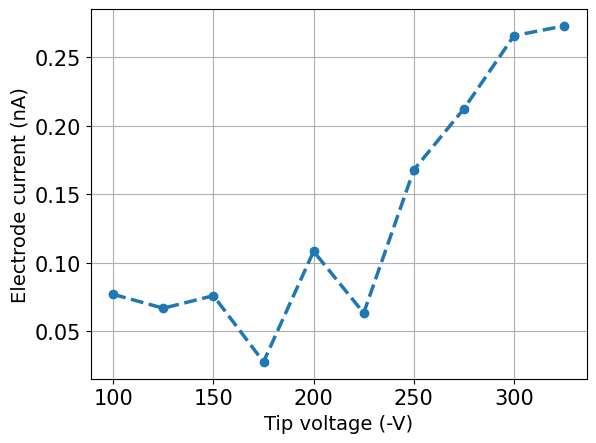

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


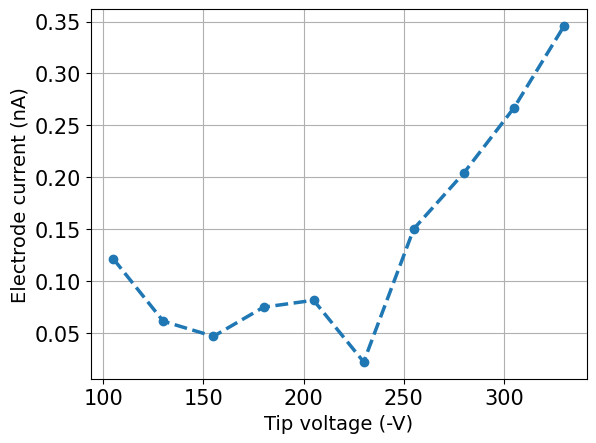

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


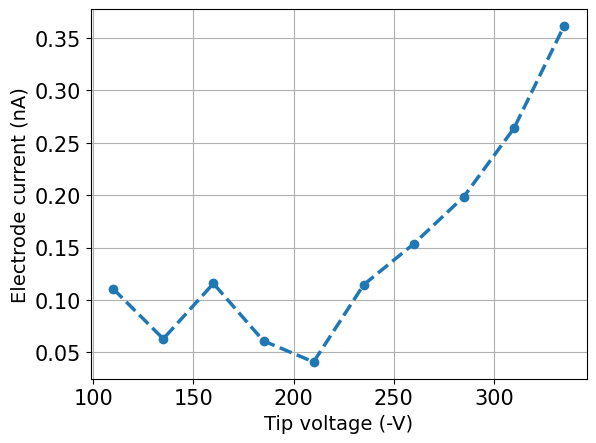

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


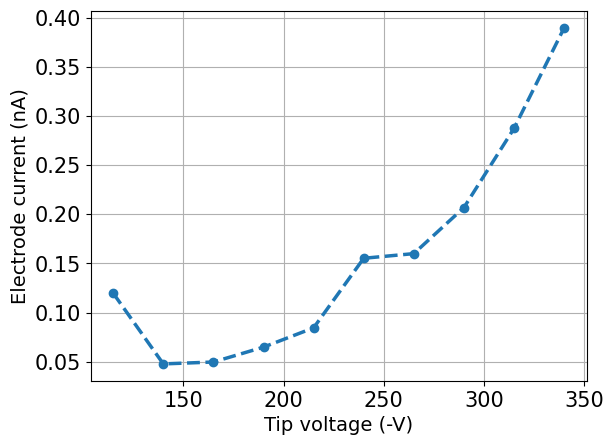

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


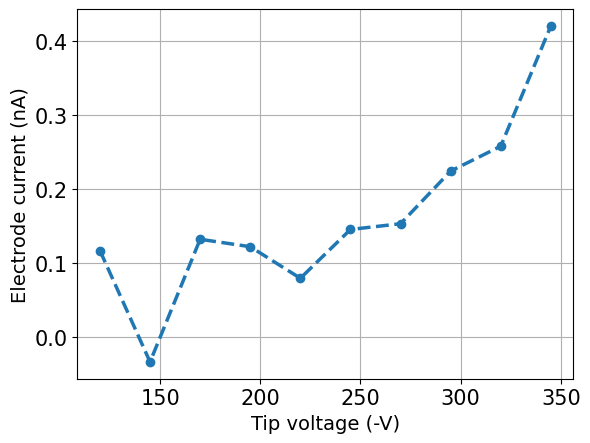

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.59s/it]


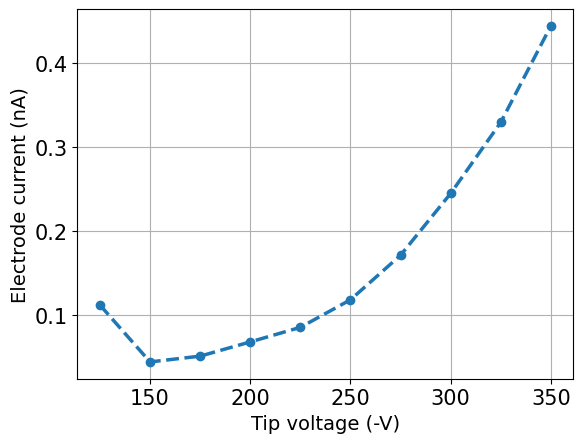

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


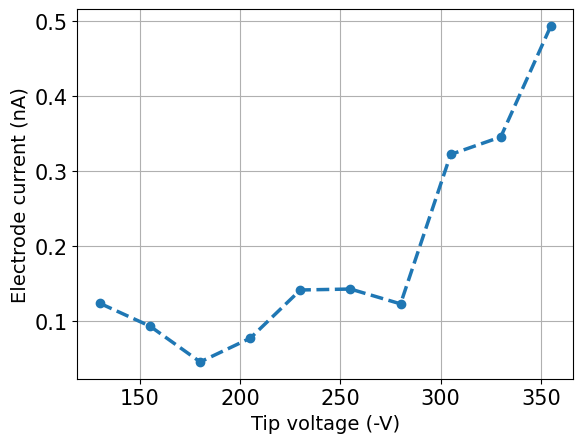

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


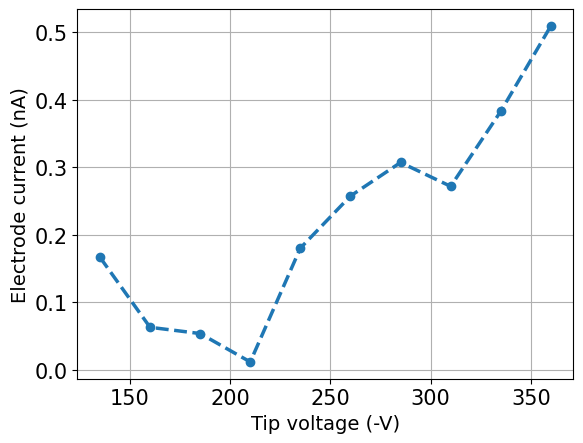

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


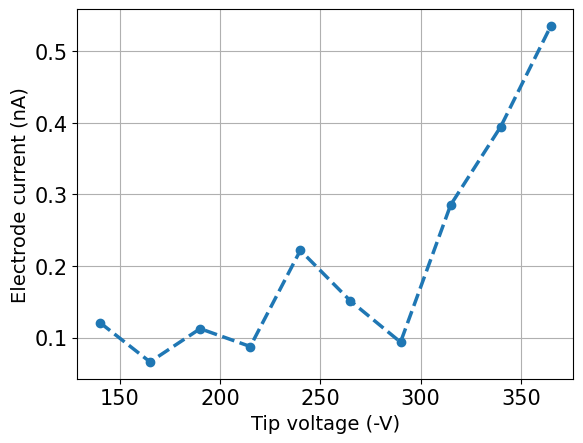

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


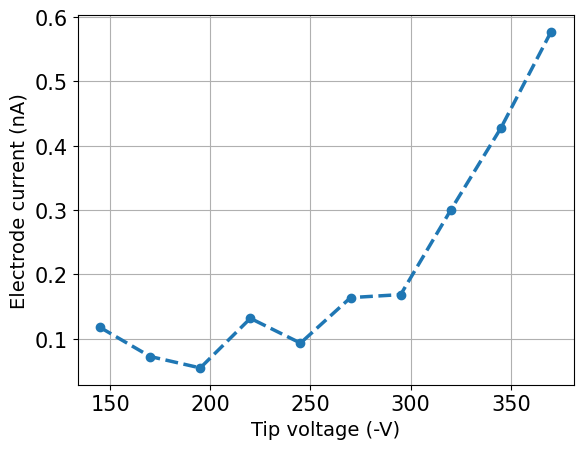

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


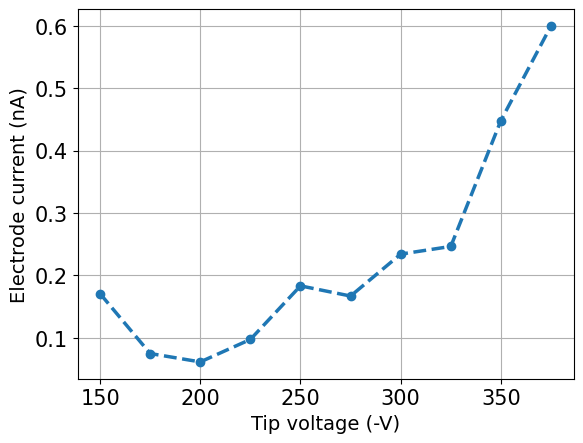

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


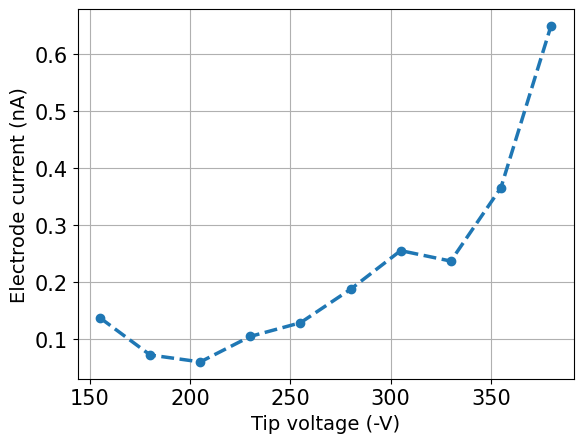

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


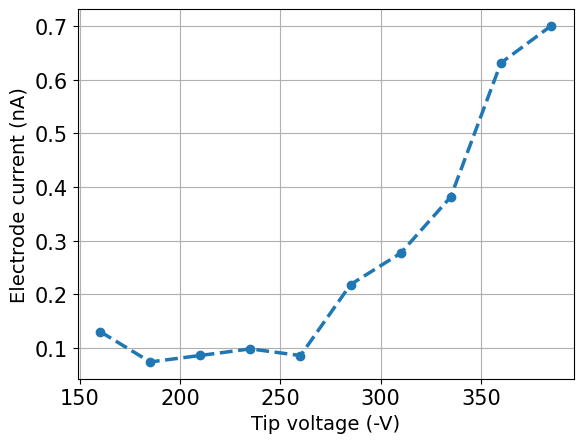

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


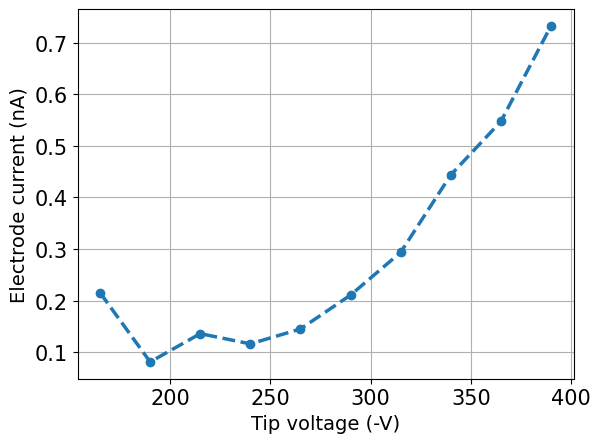

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


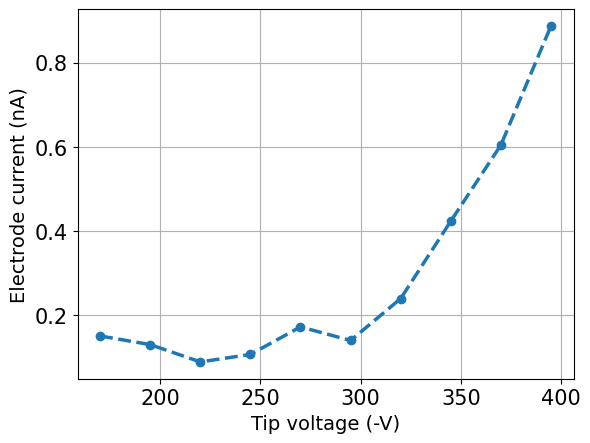

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


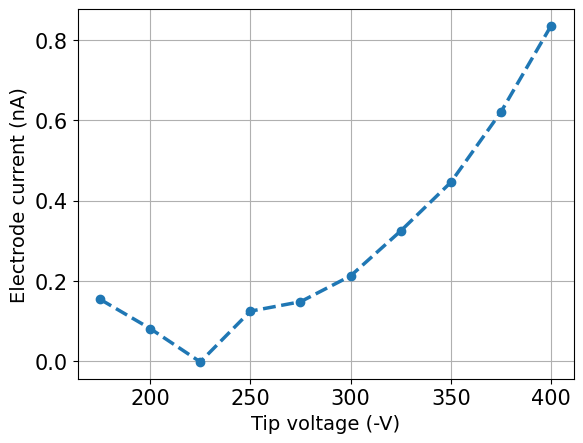

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


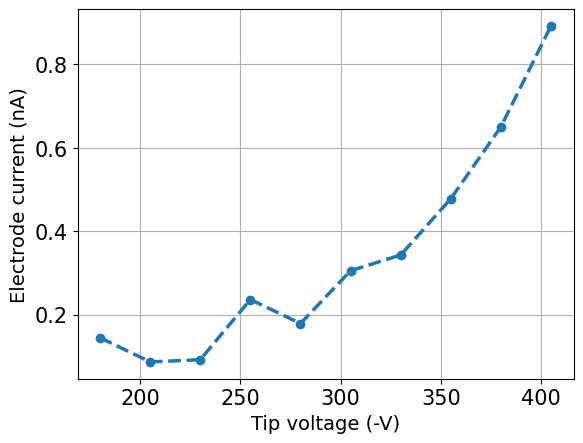

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


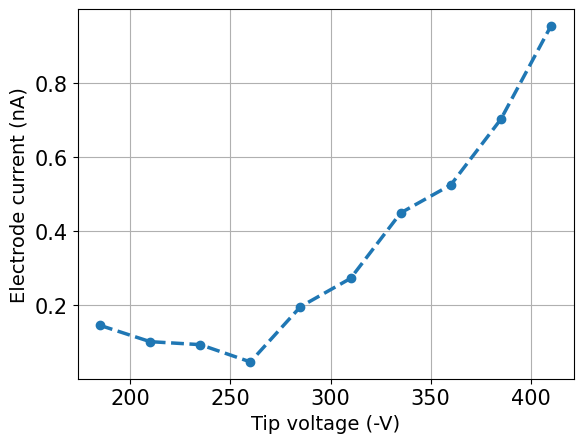

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


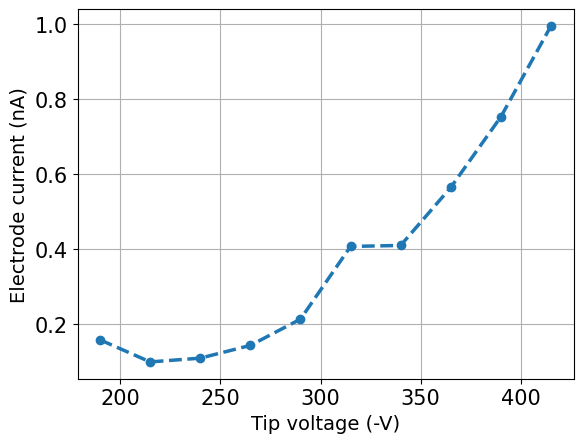

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


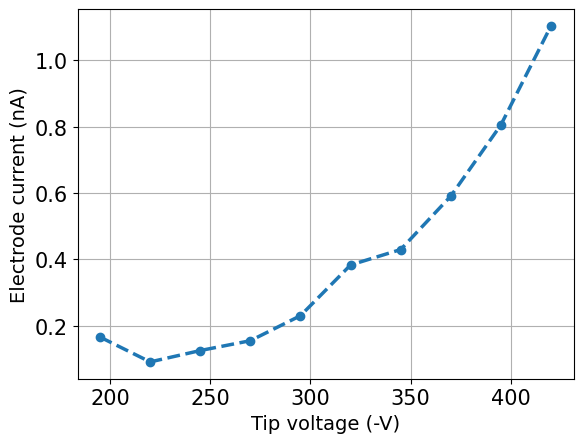

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


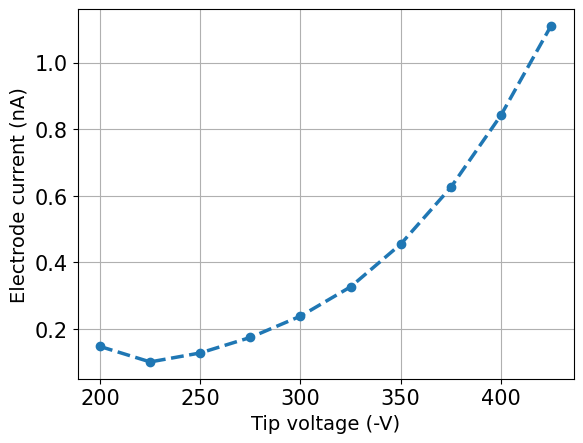

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


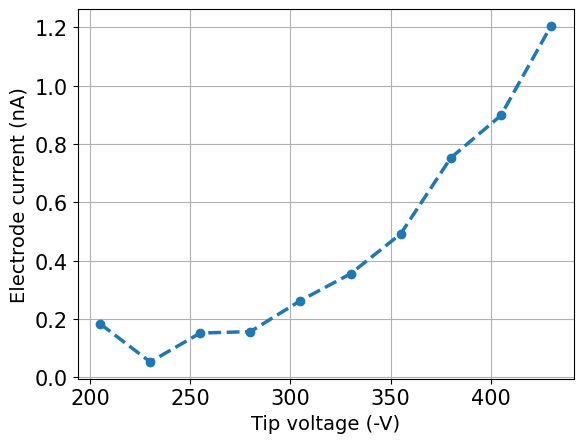

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.56s/it]


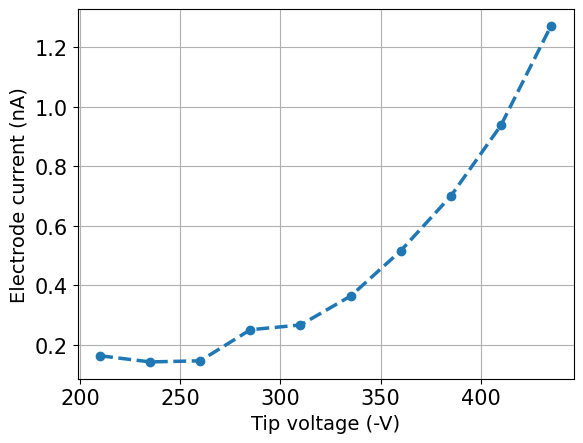

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


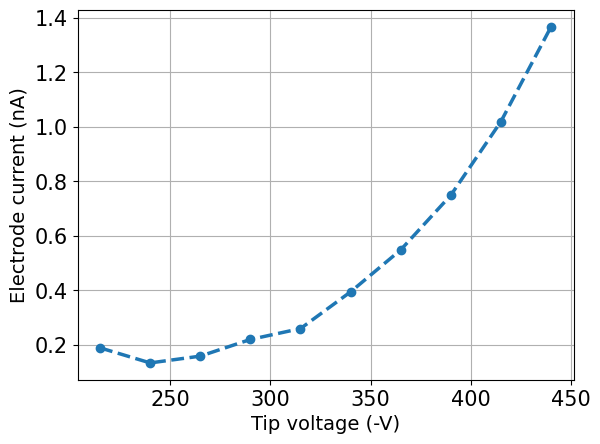

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.56s/it]


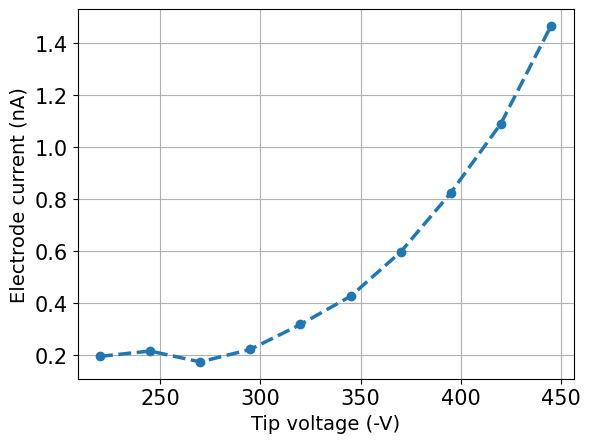

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.59s/it]


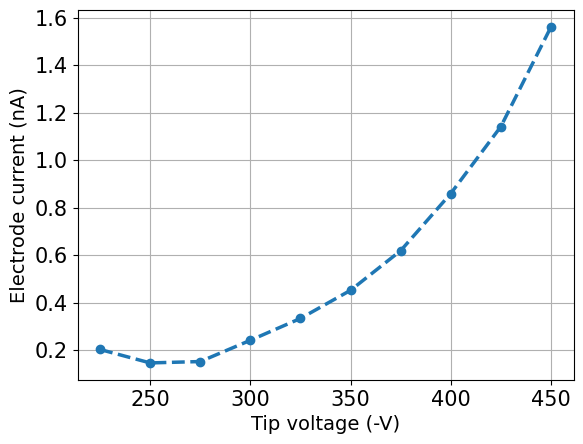

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


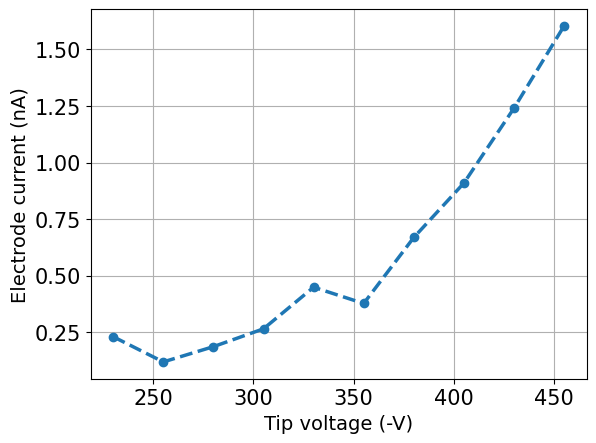

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


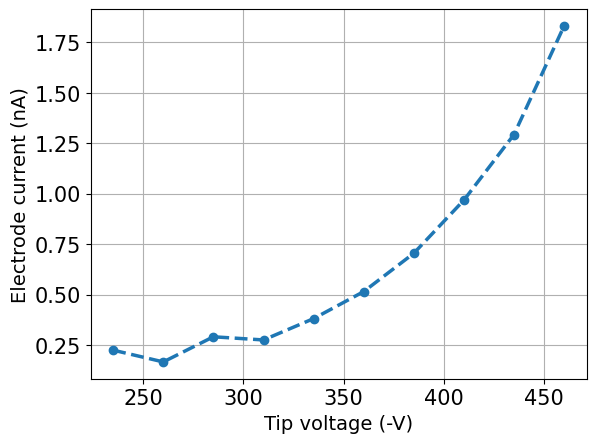

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


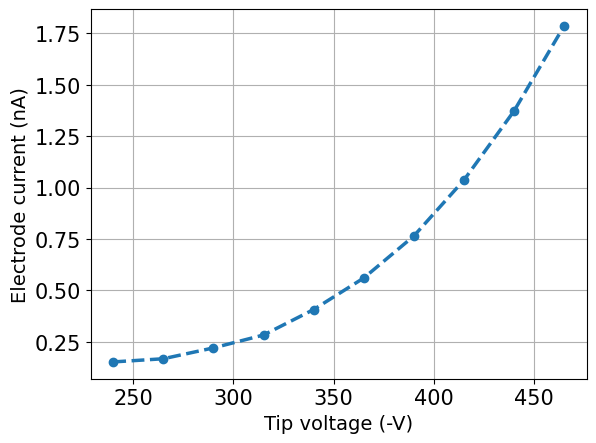

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


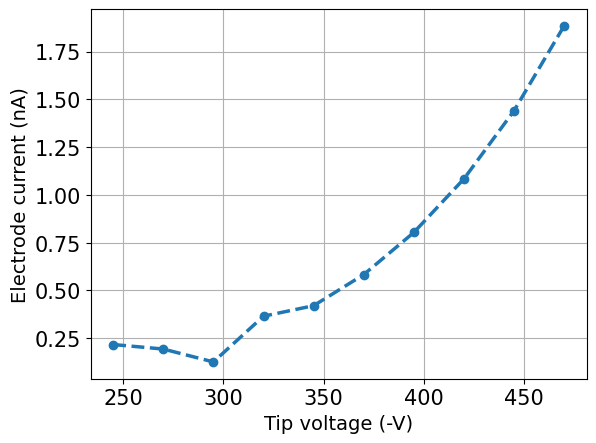

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


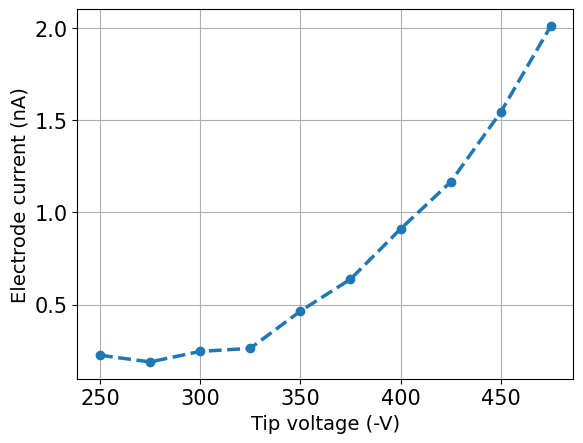

In [14]:
exp.V_tip = 300
reset_tip_V(exp, show_plot=True, V_pos=1200)

In [7]:
exp.SSA.set_VBW(10e3)

In [16]:
import random
# # all_P = [5]
# random.shuffle(all_P)
# print(all_P)
# exp.DAC.set_multipoles(Ex=0.25, U2=-0.4)
# time.sleep(5)
all_Ex = [0.5]
random.shuffle(all_Ex)
print(all_Ex)
for Ex in all_Ex:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=5, V_on=exp.V_tip, V_off=exp.V_tip-300, V_pos=1200,
                                     t_load=20, t_data=0.1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=10e3, N_avg=50, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.4)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.4, background=True)
    file = RF_sweep.run_save()
    reset_tip_V(exp, V_pos=1200)

[0.5]
RID: 10197
voltages loaded


100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.56s/it]


In [17]:
exp.V_tip

455.0

In [9]:
import random
# # all_P = [5]
# random.shuffle(all_P)
# print(all_P)
# exp.DAC.set_multipoles(Ex=0.25, U2=-0.4)
# time.sleep(5)
all_Ex = [-0.5, -0.3, 0, 0.3, 0.5]
random.shuffle(all_Ex)
print(all_Ex)
for Ex in all_Ex:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=5, V_on=exp.V_tip, V_off=exp.V_tip-300, V_pos=450,
                                     t_load=30, t_data=0.1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=10e3, N_avg=50, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.4)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.4, background=False)
    file = RF_sweep.run_save()
    reset_tip_V(exp, V_pos=450)

all_U2 = [-1, -0.7, -0.5, -0.4, -0.3]
for U2 in all_U2: 
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=5, V_on=exp.V_tip, V_off=exp.V_tip-300, V_pos=450,
                                     t_load=30, t_data=0.1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=10e3, N_avg=50, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=U2)
    RF_sweep.set_parameters(Ex=0, U2=U2, background=False)
    file = RF_sweep.run_save()
    reset_tip_V(exp, V_pos=450)

all_P_detect = [7.5,7,6,5,4,3]
for P in all_P_detect:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=P, V_on=exp.V_tip, V_off=exp.V_tip-300, V_pos=450,
                                     t_load=30, t_data=0.1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=10e3, N_avg=50, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=-0.4)
    RF_sweep.set_parameters(Ex=0, U2=-0.4, background=False)
    file = RF_sweep.run_save()
    reset_tip_V(exp, V_pos=450)

exp.Valon.output_off()

[0, 0.3, -0.5, -0.3, 0.5]
RID: 10176
voltages loaded


100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.56s/it]


RID: 10177
voltages loaded


100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.56s/it]


RID: 10178
voltages loaded


...

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


RID: 10190
voltages loaded


100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.56s/it]


RID: 10191
voltages loaded


100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.56s/it]


In [11]:
exp.FEtip_PSU.ramp_down(0)

In [12]:
import random
all_P_detect = [4.5, 4.617, 4.732, 4.846, 4.959, 5.070, 5.179, 5.288, 5.394, 5.5]
for P in all_P_detect:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisitionTipSwitched(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=P, V_on=exp.V_tip, V_off=exp.V_tip-100, V_pos=100,
                                     t_load=30, t_data=1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=50, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=-0.7)
    RF_sweep.set_parameters(Ex=0, U2=-0.7, background=False)
    file = RF_sweep.run_save()
    calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=False, I_max=35e-9)

exp.Valon.output_off()

RID: 10387
voltages loaded


  0%|                                                    | 0/11 [00:02<?, ?it/s]

>>> Warning: Current 8.313148056722689e-08 exceeds maximum allowed 3.5e-08. Stopping sweep.


RID: 10388
voltages loaded


 18%|████████                                    | 2/11 [00:07<00:34,  3.84s/it]

...

RID: 10395
voltages loaded


 64%|████████████████████████████                | 7/11 [00:20<00:11,  2.92s/it]

>>> Warning: Current 3.6488944222689077e-08 exceeds maximum allowed 3.5e-08. Stopping sweep.


RID: 10396
voltages loaded


100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.55s/it]


In [ ]:
import random
all_P_detect = [4.5, 4.617, 4.732, 4.846, 4.959, 5.070, 5.179, 5.288, 5.394, 5.5]
for P in all_P_detect:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisitionTipSwitched(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=P, V_on=exp.V_tip, V_off=exp.V_tip-100, V_pos=100,
                                     t_load=30, t_data=1, t_rest=1,
                                     SSA_freq_center=176.212e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=50, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=-0.7)
    RF_sweep.set_parameters(Ex=0, U2=-0.7, background=False)
    file = RF_sweep.run_save()
    calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=False, I_max=35e-9)

exp.Valon.output_off()

RID: 10397
voltages loaded


 36%|████████████████                            | 4/11 [00:12<00:22,  3.19s/it]

>>> Warning: Current 3.6821950630252104e-08 exceeds maximum allowed 3.5e-08. Stopping sweep.


RID: 10398
voltages loaded


100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.55s/it]


...

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.56s/it]


RID: 10405
voltages loaded


100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.59s/it]


RID: 10406
voltages loaded


  0%|                                                    | 0/50 [00:00<?, ?it/s]

In [19]:
import random
all_P_detect = [4.5]
for P in all_P_detect:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisitionTipSwitched(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=P, V_on=0, V_off=0, V_pos=0,
                                     t_load=30, t_data=1, t_rest=1,
                                     SSA_freq_center=176.212e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=-0.7)
    RF_sweep.set_parameters(Ex=0, U2=-0.7, background=True)
    file = RF_sweep.run_save()
    # calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=False, I_max=35e-9)

exp.Valon.output_off()

RID: 10409
voltages loaded


100%|███████████████████████████████████████████| 30/30 [16:26<00:00, 32.87s/it]


In [33]:
exp.Valon.set_power(8)
exp.Valon.output_off()

In [35]:
exp.V_tip

825.0

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.55s/it]


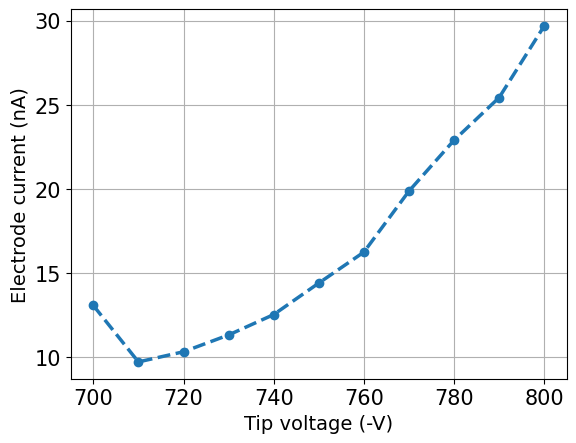

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.56s/it]


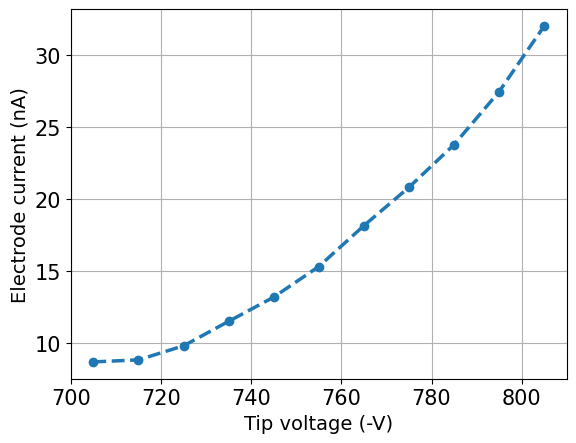

In [36]:
exp.V_tip = 800
calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=True, I_max=35e-9)

In [37]:
import random
all_P_detect = [1]
for P in all_P_detect:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisitionTipSwitched(saving_dir=exp.saving_dir, 
                                     P_load=8, P_detect=P, V_on=exp.V_tip, V_off=exp.V_tip-100, V_pos=100,
                                     t_load=30, t_data=1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=-0.7)
    RF_sweep.set_parameters(Ex=0, U2=-0.7, background=False)
    file = RF_sweep.run_save()
    calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=False, I_max=35e-9)

exp.Valon.output_off()

RID: 10418
voltages loaded


100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.56s/it]


In [40]:
exp.Valon.output_off()

In [39]:
import random
all_P_detect = [1]
for P in all_P_detect:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisitionTipSwitched(saving_dir=exp.saving_dir, 
                                     P_load=8, P_detect=P, V_on=0, V_off=0, V_pos=0,
                                     t_load=30, t_data=1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=-0.7)
    RF_sweep.set_parameters(Ex=0, U2=-0.7, background=True)
    file = RF_sweep.run_save()
    # calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=False, I_max=35e-9)

exp.Valon.output_off()

RID: 10420
voltages loaded


  0%|                                                    | 0/30 [00:23<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
beep_jupyter()

In [9]:
exp.DAC.set_multipoles(Ex=0.5, U2=-0.7)
time.sleep(5)
RF_sweep.set_parameters(Ex=0.5, U2=-0.7, background=False)
file = RF_sweep.run_save()

RID: 10058
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.13s/it]


In [ ]:
RF_sweep = RFPowerConstSweepDifferential(
    saving_dir=exp.saving_dir,
    P_valon_hold=0,
    valon_settle=2, loading_time=0, measurement_time=300,
    P_min_dBm=6, P_max_dBm=4, steps=2,  
    V_on=exp.V_tip, V_off=exp.V_tip-300, V_pos=40,
    SSA_freq_center=176.31e6, SSA_freq_span=0,
    SSA_RBW=1e3, SSA_SWT=0.1,
    Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
    N_inner=1, N_outer=1, 
    display_progress='Pscan'
)

In [4]:
RF_sweep = RFPowerConstSweepDifferential(
    saving_dir=exp.saving_dir,
    P_valon_hold=0,
    valon_settle=2, loading_time=0, measurement_time=300,
    P_min_dBm=12, P_max_dBm=5, steps=2,  
    V_on=exp.V_tip, V_off=950, V_pos=40,
    SSA_freq_center=176.31e6, SSA_freq_span=0,
    SSA_RBW=1e3, SSA_SWT=0.1,
    Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
    N_inner=1, N_outer=1, 
    display_progress='Pscan'
)
for Ex in [-0.1, 0, 0.3, 0.5, 0.7, 1.5, 3]:
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.7)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.7, background=False)
    file = RF_sweep.run_save()

for U2 in [-1, -0.7, -0.4, 1]:
    exp.DAC.set_multipoles(Ex=0, U2=U2)
    RF_sweep.set_parameters(Ex=0, U2=U2, background=False)
    file = RF_sweep.run_save()
    
beep_jupyter()


RID: 10098
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.09s/it]


RID: 10099
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.05s/it]


RID: 10100
voltages loaded


...

>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.08s/it]


RID: 10107
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.08s/it]


RID: 10108
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.14s/it]


In [110]:
exp.FEtip_PSU.ramp_down_ch('pos', 0)

In [109]:
for U2 in [-1, -0.9, -0.8, -0.7]:
    RF_sweep = RFPowerConstSweepTipSwitched(
        saving_dir=exp.saving_dir,
        P_valon_hold=5,
        valon_settle=2, loading_time=0, measurement_time=30,
        P_min_dBm=12.45, P_max_dBm=7.12, steps=2,  
        V_on=850, V_off=500, V_pos=600,
        SSA_freq_center=176.2190e6, SSA_freq_span=0,
        SSA_RBW=1e3, SSA_SWT=0.1,
        Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
        N_inner=1, N_outer=1, 
        display_progress='Pscan'
    )
    exp.DAC.set_multipoles(Ex=0, U2=U2)
    RF_sweep.set_parameters(Ex=0, U2=U2, background=False)
    file = RF_sweep.run_save()
beep_jupyter()


RID: 10015
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.07s/it]


RID: 10016
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.06s/it]


RID: 10017
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.09s/it]


RID: 10018
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.11s/it]


In [ ]:
exp.Valon.output_off()